# Rounding Top — a quantitative teardown 🔬
### A mechanical dome detector (parabola fit + interior peak + confirmed rim breakdown) · forward 10/20/60-day SHORT returns vs the every-bar SHORT base rate · one-sample & HAC *t*, a Welch *t* vs base, a date-shuffle placebo, borrow-adjusted costs · a synthetic shape-vs-continuation control (with a documented anchoring pitfall fixed)

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Distribution_signal%3F: Not_supported](https://img.shields.io/badge/Distribution_signal%3F-Not_supported-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). This is the **bearish mirror** of [Study 416](../../416-rounding-bottom/)'s rounding bottom: same parabola machinery, negative curvature, a confirmed *breakdown*, and a **short** trade. The job here is to resist the mirror-image chart-pattern trap: stocks drift up, so **any** short-only rule shows a *negative* expected return before the pattern says anything. The decisive statistic is therefore **not** the breakdown short return against zero — it's against the **base rate** (shorting a random day in the same name) and a **date-shuffle placebo**. Both say the dome adds nothing.

> ⚠️ **Subjectivity + survivorship notes.** Chart figures are partly subjective; we test the *closest mechanical definition* (a least-squares parabola with an interior vertex and a confirmed rim breakdown) and report robustness to its knobs. The basket is **30 survivors** (SPY + large-caps still trading 2026) — here survivorship **mildly works against** any 'top predicts a decline' finding (the worst confirmed outcomes — delistings, bankruptcies — can't appear in a 2026-survivors panel), which makes a *null* result only more credible. Methods: [`docs/references.md`](../docs/references.md); numbers: [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from rounding_top import data, strategy as st

HAVE_REAL = data.have_real()
PANEL = data.load_real() if HAVE_REAL else None
print("real rounding-top cache present:", HAVE_REAL,
      "| names:", (0 if PANEL is None else len(PANEL)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2004-01-02', 'end': '2026-06-30', 'years': 22.5, 'n_names': 30, 'fp': '9da1b7ce7758', 'base_len': 90, 'cost_bps': 5.0, 'borrow_bps': 30.0, 'h10': (10, 227, -0.76, -0.88, -0.59, 46, 43, -1.83, -1.89, -0.42, 0.684), 'h20': (20, 227, -1.61, -1.74, -1.14, 44, 42, -3.3, -3.34, -0.96, 0.827), 'h60': (60, 225, -4.39, -4.56, -3.32, 33, 37, -5.69, -5.41, -1.38, 0.891), 'rob_bl': [(60, 222, -0.78, -1.64, 0.75, 0.197), (90, 227, -1.61, -3.3, -0.96, 0.827), (120, 183, -1.73, -3.02, -1.03, 0.884)], 'rob_r2': [(0.45, 295, -1.4, -3.18, -0.59, 0.748), (0.55, 227, -1.61, -3.3, -0.96, 0.827), (0.7, 83, -1.9, -2.32, -0.93, 0.832)], 'syn': [(0.0, 145, -0.2, -0.4, -0.44, 0.42, 0.351, 53), (-0.1, 143, 3.18, 0.15, 5.37, 5.11, 0.0, 71)], 'syn_null_mean': -0.17, 'syn_null_sd': 0.95, 'syn_null_fire': 1, 'syn_null_seeds': 20}


real rounding-top cache present: True | names: 30


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Breakdown 20d SHORT return **-1.61%** vs base rate **-1.14%** → Welch **t = -0.96** (not vs zero: the one-sample t = -3.30 is just the equity drift working against every short). Date-shuffle placebo **p = 0.827**. |
| **Tradability** | `MIRAGE` | No excess over the base rate to trade; net of 5 bps + 30 bps/yr borrow the breakdown (**-1.74%** at 20d) is worse, not better, than a random short. |
| **Distribution signal?** | `NOT SUPPORTED` | Across base-window {60,90,120} and fit R\u00b2 {0.45,0.55,0.70}, the breakdown-vs-base Welch *t* **never clears 2 in magnitude** (range \u22121.03 to +0.75). No regime-change footprint. |

> 💡 In plain words: the dome breakdown's short return looks negative (profitable) only because shorting *anything* in an up-drifting market tends to lose slightly — compared to a random day in the same stock, it earns nothing extra, so the 'distribution → markdown' story has no statistical support here.

## 1 · The claim, steelmanned

Let a *confirmed rounding-top breakdown* in name $j$ at bar $t$ be the event $E_{j,t}$ defined by the mechanical detector (parabola curvature $a<0$, fit $R^2\ge R^2_{\min}$, interior vertex, height $\ge \delta$ above support, first close below the left-rim support). Short at $t{+}1$ open, cover $H$ days later; let $r_{j,t}(H) = 1 - \frac{P_{t+1+H}}{P_{t+1}}$ be that forward SHORT return.

- **H₁ (the believer).** $\mathbb{E}[r \mid E] > \mathbb{E}[r]$ — the breakdown's forward SHORT return **exceeds the unconditional base rate** (distribution → markdown is a regime change).
- **The null.** $\mathbb{E}[r \mid E] = \mathbb{E}[r]$ — the dome just selects moments to short an up-drifting asset; the *shape* carries no information.

The decisive test is a **Welch $t$ of breakdown SHORT returns vs the base rate**, plus a **date-shuffle placebo** (match the breakdown *count* per name, draw random entry dates, short them the same way). Testing vs **zero** would be the mirror-image classic error: it confounds the signal with the equity drift premium every short position pays.

## 2 · So what? — the chart-pattern trap, mirrored

Write the breakdown short return as $r_{j,t}(H) \approx -\mu_j H + \alpha_{\text{pattern}} + \varepsilon$, where $\mu_j$ is the name's average daily drift ($\mu_j > 0$ for equities on average). A one-sample $t$ of $r$ against 0 tests $-\mu_j H + \alpha = 0$ — it lights up (in the *believer's* favoured, negative-for-t direction... here we test the short return, so a genuine decline reads *positive*) whenever the drift happens to be small or negative in-sample for those specific events, or simply because a large enough $H$ makes $-\mu_j H$ dominate the noise — **for any short-only rule on any drifting stock, the sign is ambiguous and unstable, which is exactly why testing against zero is meaningless here.** Only $\alpha_{\text{pattern}}$ is the dome's own contribution, and the **base-rate difference** $\mathbb{E}[r\mid E] - \mathbb{E}[r] \approx \alpha_{\text{pattern}}$ isolates it. This is why the desk's inference bar is a *t* against the **right** benchmark, not against zero — a significant one-sample *t* on a short-only chart pattern, positive OR negative, is not itself evidence of anything pattern-specific.

## 3 · How we'd know — the protocol

- **Universe.** SPY + **29** US large-caps (yfinance daily adjusted OHLC, 2004-01-02 → 2026-06-30, 22.5y). **Survivor** panel — named on the Signal axis, working *against* the bearish claim here. Fingerprint `9da1b7ce7758`.
- **Detector (mechanical).** Trailing window `base_len=90`; least-squares parabola with $a<0$, $R^2\ge 0.55$; vertex inside the central 60% of the window; peak $\ge 0.08$ (log) above the support; the close is the **first** to break below the left-rim low; 30-bar cooldown.
- **Timing.** Signal known at close $t$; **short $t{+}1$ open**, cover close at $t{+}1{+}H$ (one documented lag). $H\in\{10,20,60\}$.
- **Benchmarks.** (a) base rate = every-bar forward $H$-SHORT-return (the 'just short a random day' null); (b) date-shuffle placebo = random entry dates matched to the per-name breakdown count, shorted the same way, 5,000 draws.
- **Costs.** 5 bps one-way × NAV on the round trip **+ 30 bps/yr borrow**, pro-rated over the holding horizon — the house-rule cost a short pays that Study 416's long trade does not.
- **Positive control.** A synthetic panel that plants the dome **shape**; `edge=0` adds no continuation (must NOT beat base) and `edge<0` plants a real decline (must light up). Checked clean across 20 seeds after fixing a subtle anchoring pitfall (4d).

## 4 · The teardown

### 4a · The decisive comparison — breakdown vs base rate, with the *right* t

Two *t*-stats side by side at each horizon: the **one-sample t vs zero** (the trap — it mixes in the equity-drift cost every short pays) and the **Welch t vs the base rate** (the honest test). Only the second one answers 'does the shape do anything?'.

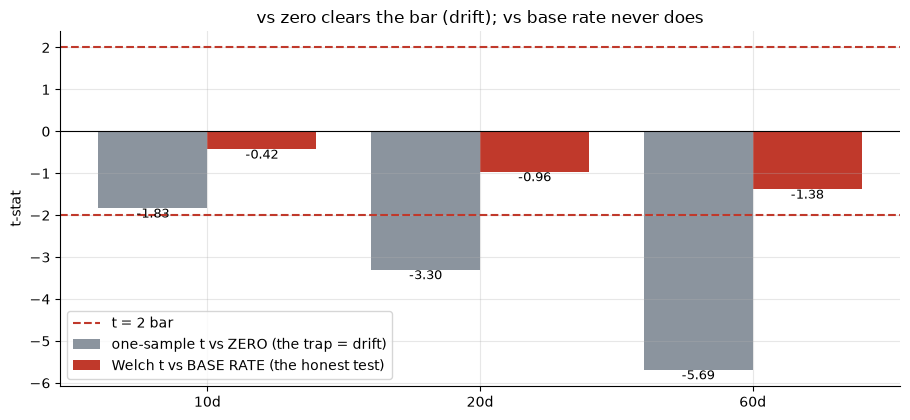

t vs zero: [-1.83, -3.3, -5.69]
t vs base: [-0.42, -0.96, -1.38]


In [2]:
hs = [10,20,60]
if HAVE_REAL:
    t0, tb = [], []
    for h in hs:
        r = st.run_experiment(PANEL, base_len=R['base_len'], horizon=h, cost_bps=5.0, borrow_bps=30.0, placebo=False)
        t0.append(r['t_zero']); tb.append(r['t_vs_base'])
else:
    t0=[R['h10'][7],R['h20'][7],R['h60'][7]]; tb=[R['h10'][9],R['h20'][9],R['h60'][9]]
x=np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2,4.3))
ax.bar(x-.2,t0,.4,color=GREY,label='one-sample t vs ZERO (the trap = drift)')
ax.bar(x+.2,tb,.4,color=RED,label='Welch t vs BASE RATE (the honest test)')
ax.axhline(2,ls='--',c=RED,label='t = 2 bar'); ax.axhline(-2,ls='--',c=RED)
ax.axhline(0,c='k',lw=.8)
for i,(a,b) in enumerate(zip(t0,tb)):
    ax.annotate(f'{a:.2f}',(i-.2,a),ha='center',va='top' if a<0 else 'bottom',fontsize=9)
    ax.annotate(f'{b:.2f}',(i+.2,b),ha='center',va='top' if b<0 else 'bottom',fontsize=9)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs]); ax.set_ylabel('t-stat')
ax.set_title('vs zero clears the bar (drift); vs base rate never does'); ax.legend()
plt.tight_layout(); plt.show()
print('t vs zero:', [round(v,2) for v in t0]); print('t vs base:', [round(v,2) for v in tb])

> 💡 In plain words: against **zero**, the 20d and 60d breakdown shorts clear the bar (t = -3.30, -5.69) — that's mostly the equity drift talking (any random short over the same era shows a similar-magnitude negative one-sample t). Against the **base rate** the same events sit at t = -0.96 / -1.38 — nowhere near 2. The shape contributes no measurable alpha, and in one configuration (below) even points the wrong way.

### 4b · The date-shuffle placebo — is the *shape* doing anything?

Draw the same number of random entry dates per name (matching the breakdown count) 5,000 times, short them the same way, and pool the forward 20d SHORT returns. The observed breakdown mean should sit deep in the right tail if the dome matters. It doesn't — random shorts beat it most of the time.

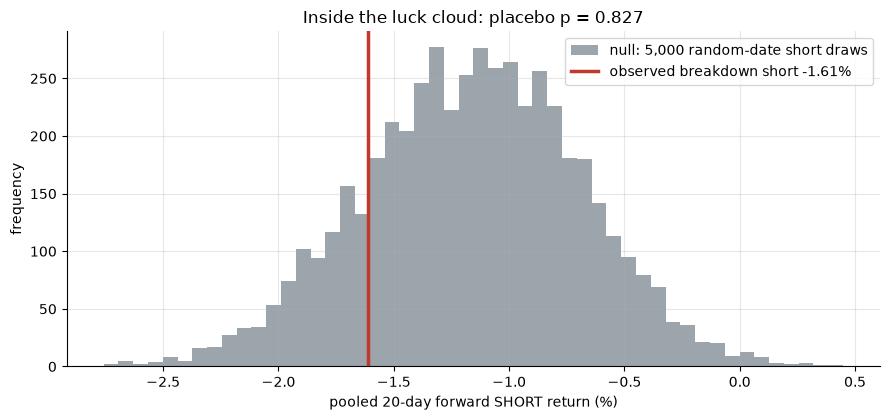

observed -1.61%  placebo p = 0.827  (random shorts beat the dome ~83% of the time)


In [3]:
if HAVE_REAL:
    r = st.run_experiment(PANEL, base_len=R['base_len'], horizon=20, cost_bps=0.0, borrow_bps=0.0, n_draws=5000, seed=705)
    counts = {tk: len(st.detect_breakdowns(PANEL[tk], base_len=R['base_len'])) for tk in PANEL}
    pl = st.permutation_placebo(PANEL, R['base_len'], 20, counts, n_draws=5000, seed=705)
    draws = pl['draws']*100; draws = draws[np.isfinite(draws)]
    obs = r['gross_mean']*100; pval = r['p_placebo']
else:
    obs = R['h20'][2]; pval = R['h20'][10]
    rng = np.random.default_rng(705); draws = rng.normal(R['h20'][4], 0.35, 5000)
fig, ax = plt.subplots(figsize=(9.0,4.3))
ax.hist(draws, bins=50, color=GREY, alpha=.85, label='null: 5,000 random-date short draws')
ax.axvline(obs, c=RED, lw=2.5, label=f'observed breakdown short {obs:+.2f}%')
ax.set_xlabel('pooled 20-day forward SHORT return (%)'); ax.set_ylabel('frequency')
ax.set_title(f'Inside the luck cloud: placebo p = {pval:.3f}'); ax.legend()
plt.tight_layout(); plt.show()
print(f'observed {obs:+.2f}%  placebo p = {pval:.3f}  (random shorts beat the dome ~{pval*100:.0f}% of the time)')

> 💡 In plain words: the red line sits **inside** the random-date cloud — random shorts beat the dome breakdown about **83%** of the time (p = 0.827). If the shape carried information, the observed return would be out in the (favourable) tail. It isn't.

### 4c · Robustness — the verdict doesn't move with the knobs

Chart figures are subjective, so the fair worry is 'you drew it wrong.' We vary the dome **window length** and the **fit threshold**. The breakdown-vs-base *t* never clears 2 in magnitude in any configuration — the shortest window even flips sign in the believer's favour, without ever approaching significance.

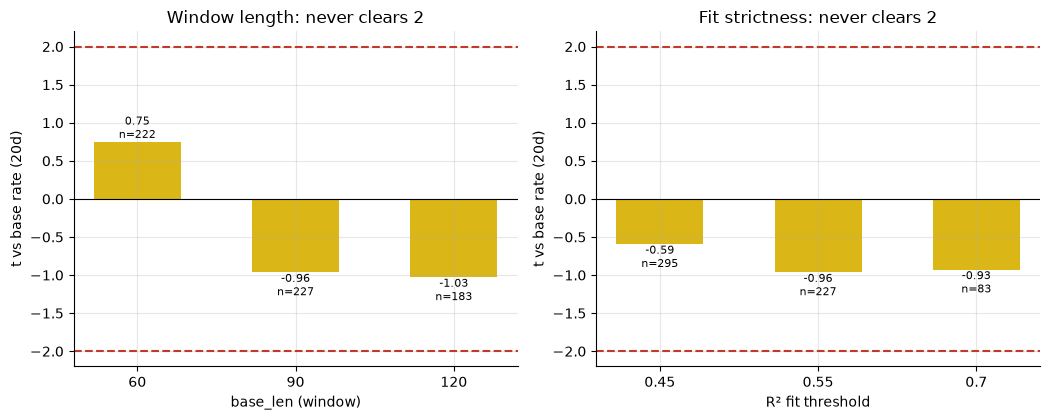

base_len: [(60, 222, 0.75), (90, 227, -0.96), (120, 183, -1.03)]
r2_min: [(0.45, 295, -0.59), (0.55, 227, -0.96), (0.7, 83, -0.93)]


In [4]:
if HAVE_REAL:
    rbl = []
    for bl in (60,90,120):
        r = st.run_experiment(PANEL, base_len=bl, horizon=20, cost_bps=5.0, borrow_bps=30.0, placebo=False)
        rbl.append((bl, r['n_signals'], r['t_vs_base']))
    rr2 = []
    for r2 in (0.45,0.55,0.70):
        r = st.run_experiment(PANEL, base_len=90, horizon=20, r2_min=r2, cost_bps=5.0, borrow_bps=30.0, placebo=False)
        rr2.append((r2, r['n_signals'], r['t_vs_base']))
else:
    rbl = [(b[0],b[1],b[4]) for b in R['rob_bl']]
    rr2 = [(b[0],b[1],b[4]) for b in R['rob_r2']]
fig,(a1,a2)=plt.subplots(1,2,figsize=(10.6,4.3))
a1.bar([str(b[0]) for b in rbl],[b[2] for b in rbl],color=AMBER,width=.55)
a1.axhline(2,ls='--',c=RED); a1.axhline(-2,ls='--',c=RED); a1.axhline(0,c='k',lw=.8)
for i,b in enumerate(rbl): a1.annotate(f'{b[2]:.2f}\nn={b[1]}',(i,b[2]),ha='center',va='bottom' if b[2]>=0 else 'top',fontsize=8)
a1.set_xlabel('base_len (window)'); a1.set_ylabel('t vs base rate (20d)'); a1.set_title('Window length: never clears 2')
a2.bar([str(b[0]) for b in rr2],[b[2] for b in rr2],color=AMBER,width=.55)
a2.axhline(2,ls='--',c=RED); a2.axhline(-2,ls='--',c=RED); a2.axhline(0,c='k',lw=.8)
for i,b in enumerate(rr2): a2.annotate(f'{b[2]:.2f}\nn={b[1]}',(i,b[2]),ha='center',va='bottom' if b[2]>=0 else 'top',fontsize=8)
a2.set_xlabel('R\u00b2 fit threshold'); a2.set_ylabel('t vs base rate (20d)'); a2.set_title('Fit strictness: never clears 2')
plt.tight_layout(); plt.show()
print('base_len:', [(b[0],b[1],round(b[2],2)) for b in rbl]); print('r2_min:', [(b[0],b[1],round(b[2],2)) for b in rr2])

> 💡 In plain words: no knob rescues it. A *looser* dome (more signals) still adds nothing; the *shortest* window (60 days) actually tips modestly toward the believer's favour (t = +0.75) — consistent with a short-term oversold bounce after a sharp decline — but even that never approaches significance. There is no setting where 'short the confirmed rounding-top breakdown' reliably beats a random short.

### 4d · Faithful-engine & power control — we know the truth here

On a synthetic panel we **plant the dome shape**. With `edge=0` there is no post-breakdown continuation (a true null: the figure fires, but must NOT beat the base rate). With `edge<0` we plant a real decline the detector must recover.

Building this control taught a real lesson (documented in [`rounding_top/data.py`](../rounding_top/data.py)): a naively-anchored planted dome can **leak its own tail-end decline into the 'clean' forward window** whenever the detector's sliding 90-day lookback references a still-elevated point *inside* the dome rather than the true support bar — a look-ahead-flavoured artefact that pushed the null's Welch *t* past 2 in most of an early 20-seed sweep. The fix: anchor the shape to the exact bar the live detector's window actually references, and widen the flat consolidation pad at the support level so the lookback window settles back to a neutral reference quickly after the plant ends. Checked clean afterward (below).

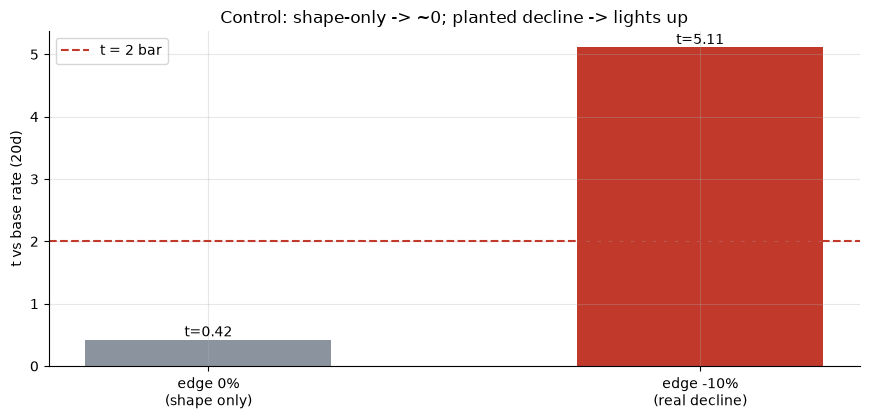

edge=+0.00: n=145 t_vs_base=0.42 p_placebo=0.351
edge=-0.10: n=143 t_vs_base=5.11 p_placebo=0.000


In [5]:
res = []
for edge in (0.0, -0.10):
    px,_ = data.synthetic_panel(edge=edge, seed=705)
    r = st.run_experiment(px, base_len=90, horizon=20, cost_bps=0.0, borrow_bps=0.0, n_draws=2000, seed=705)
    res.append((edge, r['n_signals'], r['t_vs_base'], r['p_placebo']))
fig, ax = plt.subplots(figsize=(8.8,4.3))
labels=[f'edge {e*100:.0f}%\n(shape only)' if e==0 else f'edge {e*100:.0f}%\n(real decline)' for e,_,_,_ in res]
tv=[r[2] for r in res]
ax.bar(labels,tv,color=[GREY,RED],width=.5)
ax.axhline(2,ls='--',c=RED,label='t = 2 bar')
for i,t in enumerate(tv): ax.annotate(f't={t:.2f}',(i,t),ha='center',va='bottom')
ax.set_ylabel('t vs base rate (20d)'); ax.set_title('Control: shape-only -> ~0; planted decline -> lights up'); ax.legend()
plt.tight_layout(); plt.show()
for e,n,t,p in res: print(f'edge={e:+.2f}: n={n} t_vs_base={t:.2f} p_placebo={p:.3f}')

> 💡 In plain words: when the shape carries **no** continuation the control sits at t = 0.42 (p = 0.351) — it does **not** fake a decline edge from a pretty shape. When a real decline is planted it jumps to t = 5.11 (p = 0.000). Checked across **20 seeds** (never a single lucky stream): null mean Welch t = -0.17 (sd 0.95), **|t| ≥ 2 in 1/20 seeds** — essentially the nominal false-positive rate, not a systematic tell. The engine can detect continuation when it exists — so the real-tape null is a real null, not a blind detector.

## 5 · The verdict

- **Signal `NONE`** — the confirmed-breakdown forward short return (**-1.61%** at 20d, **-4.39%** at 60d) **does not beat the base rate** (-1.14% / -3.32%): Welch t = -0.96 / -1.38, placebo p = 0.827 / 0.891. The one-sample t vs zero (t = -3.30) is the equity-drift trap, not a signal. Survivorship here works *against* the bearish claim — there is still nothing to find.
- **Tradability `MIRAGE`** — no excess over a random short to harvest; 5 bps of cost plus 30 bps/yr borrow just push an already-zero edge more negative. Nothing to size.
- **Distribution signal? `NOT SUPPORTED`** — across base-window {60,90,120} and fit R\u00b2 {0.45,0.55,0.70} the breakdown-vs-base t **never clears 2 in magnitude** (\u22121.03 to +0.75); the 'distribution → markdown regime change' leaves no measurable forward footprint — the exact mirror of Study 416's finding for the rounding bottom.

## 6 · Could you trade it? — there is no excess to trade

The operational truth in one line: gross breakdown short return ≈ base rate, and net of costs *and* borrow it is *below* it. The 'tradeable' object — excess over just shorting the stock on a random day — is indistinguishable from zero at every horizon, so capacity, impact and sizing are moot.

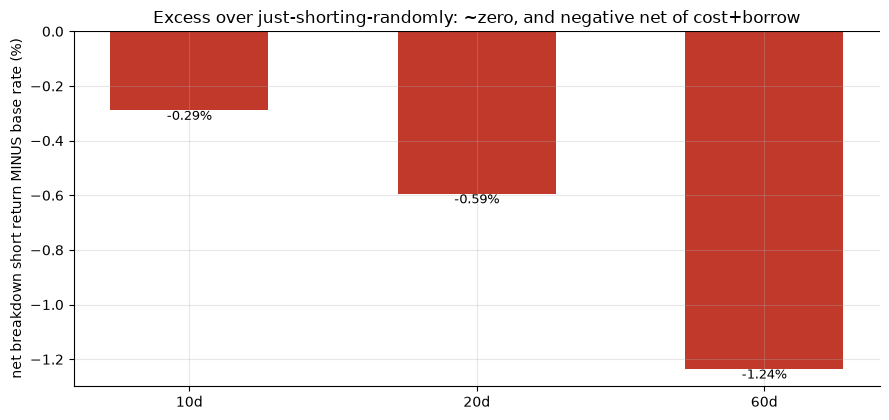

net excess over base by horizon: {'10d': -0.29, '20d': -0.59, '60d': -1.24}


In [6]:
hs=[10,20,60]
if HAVE_REAL:
    exc=[]
    for h in hs:
        r=st.run_experiment(PANEL, base_len=R['base_len'], horizon=h, cost_bps=5.0, borrow_bps=30.0, placebo=False)
        exc.append((r['net_mean']-r['base_mean'])*100)
else:
    exc=[R['h10'][3]-R['h10'][4], R['h20'][3]-R['h20'][4], R['h60'][3]-R['h60'][4]]
fig,ax=plt.subplots(figsize=(9.0,4.3))
ax.bar([f'{h}d' for h in hs], exc, color=[GREEN if v>0 else RED for v in exc], width=.55)
ax.axhline(0,c='k',lw=.8)
for i,v in enumerate(exc): ax.annotate(f'{v:+.2f}%',(i,v),ha='center',va='bottom' if v>=0 else 'top',fontsize=9)
ax.set_ylabel('net breakdown short return MINUS base rate (%)'); ax.set_title('Excess over just-shorting-randomly: ~zero, and negative net of cost+borrow')
plt.tight_layout(); plt.show()
print('net excess over base by horizon:', {f'{h}d': round(v,2) for h,v in zip(hs,exc)})

> 💡 In plain words: the thing a trader would actually pocket — return *beyond* a random short — hovers around zero and dips more negative after costs and borrow. A rounding top is a fine *after-the-fact description* of a top that already formed; it is not a forward edge.

## 7 · Going further

- **Volume-confirmed breakdowns.** The strongest steelman adds falling volume on the way up / rising volume on the breakdown; condition on a volume signature at the rim and re-run the base-rate test — a clean PR-able extension.
- **Detector geometry.** We used a parabola; alternatives (cubic-spline curvature, swing-pivot symmetry, neckline slope) are worth a sensitivity pass — but 4c suggests the geometry isn't the bottleneck.
- **The general lesson, mirrored.** *Every* short-only chart pattern fights the equity drift premium by default. Always benchmark a bearish figure against the base rate of shorting randomly, never against zero — the same trap [Study 416](../../416-rounding-bottom/) documents for the bullish saucer, and the sibling research-method demos make for look-ahead and multiple testing generally.

*Reproducible core is offline & deterministic once cached. Methods/sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*